<a href="https://colab.research.google.com/github/troncal10/gdp-dashboard/blob/main/Hermes%20despensa_atlantica_pedidos_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELDA 1: Instalación de librerías necesarias
# Instalamos pandas para manipulación de datos, scikit-learn para el modelo y escalado,
# matplotlib y seaborn para gráficos, y gradio para la interfaz interactiva.
!pip install pandas scikit-learn matplotlib seaborn gradio -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import gradio as gr
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías instaladas correctamente.")

✅ Librerías instaladas correctamente.


In [4]:
# CELDA 2: Carga de datos
# Cargamos el CSV subido a Colab. Asegúrate de que el nombre del archivo sea exacto.
# Si no lo encuentra, mostrará un error.
df = pd.read_csv('despensa_atlantica_pedidos - despensa_atlantica_pedidos.csv')
print(f"📊 Registros iniciales cargados: {len(df)}")
print(f"👥 Clientes únicos iniciales: {df['id_cliente'].nunique()}")
df.head()

📊 Registros iniciales cargados: 3869
👥 Clientes únicos iniciales: 520


,id_pedido,id_cliente,fecha_pedido,canal,categoria_principal,unidades,importe_total,provincia_envio
0,PED-501171,CLI-1109,2025-05-10,Web,Cestas regalo,9,196.29,Las Palmas
1,PED-500110,CLI-1008,2025-05-25,Web,Vinos y licores,5,84.50,Santa Cruz de Tenerife
2,PED-501309,CLI-1151,2025-05-02,Web,Cestas regalo,3,177.11,Santa Cruz de Tenerife
3,PED-500769,CLI-1051,2025-05-24,Tienda,Vinos y licores,10,92.51,Santa Cruz de Tenerife
4,PED-503451,CLI-1387,2025-04-02,Web,Cafe y gofio,5,81.65,Santa Cruz de Tenerife


In [5]:
# CELDA 3: Limpieza de datos (Paso 1 del encargo)
# 1. Eliminamos duplicados exactos
duplicados_antes = len(df)
df = df.drop_duplicates()
duplicados_eliminados = duplicados_antes - len(df)
print(f"🧹 Duplicados exactos eliminados: {duplicados_eliminados}")

# 2. Tratamiento de devoluciones (empiezan por 'DEV-')
# DECISIÓN METODOLÓGICA: Se eliminan del cálculo RFM para que la "Frecuencia"
# refleje solo transacciones de compra válidas y positivas, evitando distorsiones.
devoluciones = df[df['id_pedido'].str.startswith('DEV-', na=False)]
devoluciones_eliminadas = len(devoluciones)
df = df[~df['id_pedido'].str.startswith('DEV-', na=False)]
print(f"🧹 Registros de devoluciones (DEV-) eliminados: {devoluciones_eliminadas}")

# 3. Tratamiento de valores ausentes en provincia_envio
# No afecta al RFM, pero por limpieza imputamos "No especificada"
ausentes_provincia = df['provincia_envio'].isna().sum()
df['provincia_envio'] = df['provincia_envio'].fillna('No especificada')
print(f"🧹 Registros con provincia_envio ausente imputados: {ausentes_provincia}")

print(f"\n✅ REGISTROS FINALES PARA EL MODELO: {len(df)}")
print(f"✅ CLIENTES ÚNICOS FINALES: {df['id_cliente'].nunique()}")

🧹 Duplicados exactos eliminados: 12
🧹 Registros de devoluciones (DEV-) eliminados: 18
🧹 Registros con provincia_envio ausente imputados: 25

✅ REGISTROS FINALES PARA EL MODELO: 3839
✅ CLIENTES ÚNICOS FINALES: 520


In [6]:
# CELDA 4: Construcción de métricas RFM (Paso 2 del encargo)
# Fecha de referencia: 1 de septiembre de 2026
fecha_referencia = pd.to_datetime('2026-09-01')
df['fecha_pedido'] = pd.to_datetime(df['fecha_pedido'])

# Calculamos Recencia, Frecuencia e Importe por cliente
rfm = df.groupby('id_cliente').agg(
    Recencia=('fecha_pedido', lambda x: (fecha_referencia - x.max()).days),
    Frecuencia=('id_pedido', 'count'),
    Importe=('importe_total', 'sum')
).reset_index()

print("✅ Métricas RFM calculadas correctamente.")
rfm.head()

✅ Métricas RFM calculadas correctamente.


,id_cliente,Recencia,Frecuencia,Importe
0,CLI-1001,15,11,697.52
1,CLI-1002,30,10,952.44
2,CLI-1003,20,21,1871.66
3,CLI-1004,10,10,913.52
4,CLI-1005,10,19,1630.69


### Distribución de las Métricas RFM
Vamos a visualizar la distribución de cada una de las métricas RFM para entender mejor los rangos y la dispersión de los datos.

In [ ]:
# Distribución de Recencia
plt.figure(figsize=(10, 6))
sns.histplot(rfm['Recencia'], bins=30, kde=True)
plt.title('Distribución de Recencia')
plt.xlabel('Recencia (días desde la última compra)')
plt.ylabel('Número de clientes')
plt.show()

In [ ]:
# Distribución de Frecuencia
plt.figure(figsize=(10, 6))
sns.histplot(rfm['Frecuencia'], bins=30, kde=True)
plt.title('Distribución de Frecuencia')
plt.xlabel('Frecuencia (número de compras)')
plt.ylabel('Número de clientes')
plt.show()

In [ ]:
# Distribución de Importe
plt.figure(figsize=(10, 6))
sns.histplot(rfm['Importe'], bins=30, kde=True)
plt.title('Distribución de Importe')
plt.xlabel('Importe (gasto total)')
plt.ylabel('Número de clientes')
plt.show()

### Visualización conjunta de Frecuencia e Importe


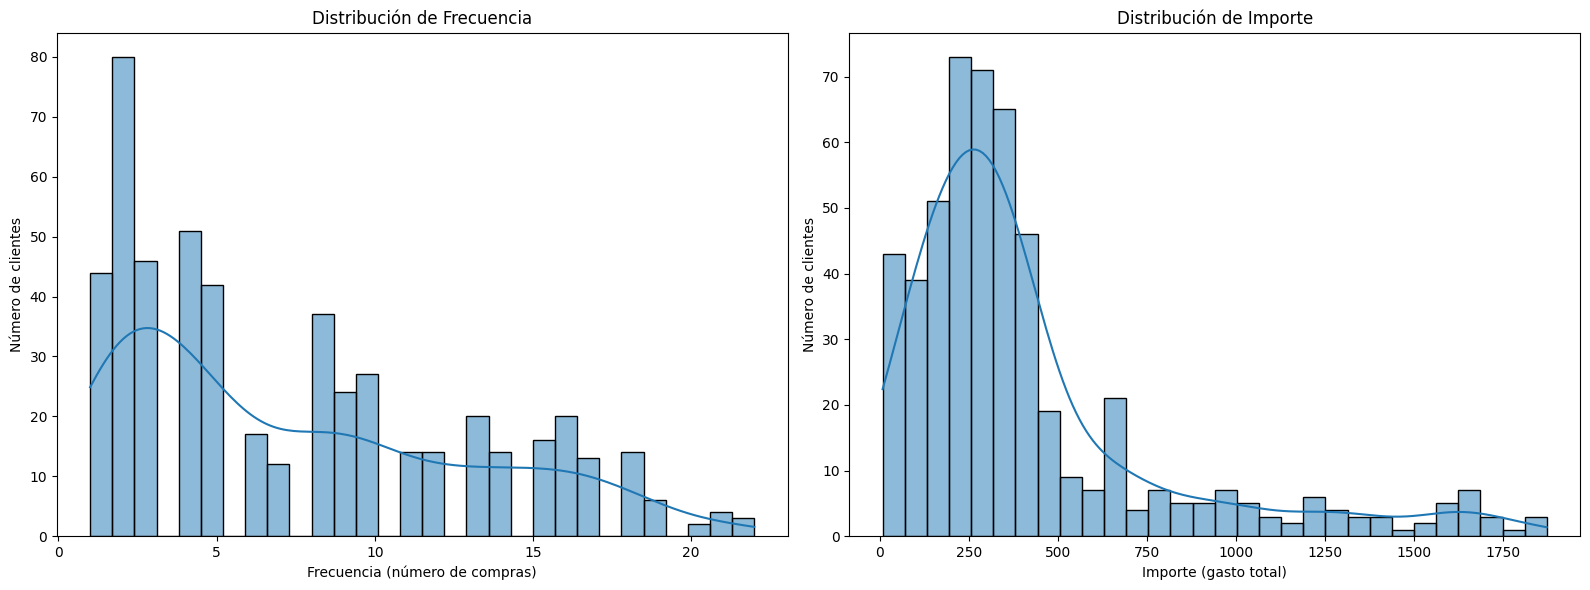

In [11]:
plt.figure(figsize=(16, 6))

# Subplot para Frecuencia
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.histplot(rfm['Frecuencia'], bins=30, kde=True)
plt.title('Distribución de Frecuencia')
plt.xlabel('Frecuencia (número de compras)')
plt.ylabel('Número de clientes')

# Subplot para Importe
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.histplot(rfm['Importe'], bins=30, kde=True)
plt.title('Distribución de Importe')
plt.xlabel('Importe (gasto total)')
plt.ylabel('Número de clientes')

plt.tight_layout() # Ajusta automáticamente los parámetros de la subtrama para que quepan en el área de la figura.
plt.show()

In [7]:
# CELDA 5: Escalado de variables (Paso 3 del encargo - CRÍTICO)
# Escalamos porque Recencia está en cientos de días e Importe en cientos de euros.
# Sin escalar, la variable con mayor magnitud numérica dominaría el algoritmo.
scaler = StandardScaler()
rfm_escalado = scaler.fit_transform(rfm[['Recencia', 'Frecuencia', 'Importe']])
print("✅ Variables escaladas con StandardScaler.")

✅ Variables escaladas con StandardScaler.


K=2 | Coeficiente de Silueta: 0.4407
K=3 | Coeficiente de Silueta: 0.4436
K=4 | Coeficiente de Silueta: 0.5194
K=5 | Coeficiente de Silueta: 0.5107
K=6 | Coeficiente de Silueta: 0.5185
K=7 | Coeficiente de Silueta: 0.5263
K=8 | Coeficiente de Silueta: 0.5097


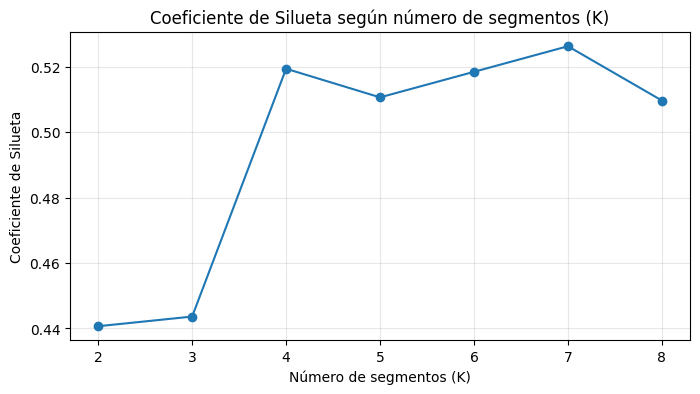

In [8]:
# CELDA 6: Evaluación del Coeficiente de Silueta para distintos K (Paso 4)
# Probamos de 2 a 8 segmentos para observar la métrica de separación.
silhouette_scores = {}
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = kmeans.fit_predict(rfm_escalado)
    score = silhouette_score(rfm_escalado, etiquetas)
    silhouette_scores[k] = score
    print(f"K={k} | Coeficiente de Silueta: {score:.4f}")

# Gráfico de evolución del coeficiente de silueta
plt.figure(figsize=(8, 4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o')
plt.title('Coeficiente de Silueta según número de segmentos (K)')
plt.xlabel('Número de segmentos (K)')
plt.ylabel('Coeficiente de Silueta')
plt.xticks(range(2, 9))
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# CELDA 7: Interfaz Gradio para probar segmentos y ver perfiles (Paso 5)
# Esta interfaz permite elegir K y ver inmediatamente la tabla de perfiles y un gráfico.

def analizar_segmentos(n_clusters):
    # Ajustar modelo con el K elegido
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    rfm['Segmento'] = kmeans.fit_predict(rfm_escalado)

    # Calcular estadísticas por segmento
    perfil = rfm.groupby('Segmento').agg(
        Clientes=('id_cliente', 'count'),
        Recencia_Media=('Recencia', 'mean'),
        Frecuencia_Media=('Frecuencia', 'mean'),
        Importe_Medio=('Importe', 'mean')
    ).round(2).reset_index()

    perfil['Porcentaje'] = (perfil['Clientes'] / len(rfm) * 100).round(1).astype(str) + '%'

    # Crear gráfico de dispersión (usamos PCA simplificado o dos variables para 2D)
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=rfm,
        x='Frecuencia',
        y='Importe',
        hue='Segmento',
        palette='viridis',
        s=60,
        alpha=0.8
    )
    plt.title(f'Distribución de Clientes por Segmento (K={n_clusters})')
    plt.xlabel('Frecuencia (Nº de pedidos)')
    plt.ylabel('Importe Total (€)')
    plt.legend(title='Segmento')
    plt.grid(True, alpha=0.3)

    return perfil, plt.gcf()

# Lanzar la interfaz Gradio
iface = gr.Interface(
    fn=analizar_segmentos,
    inputs=gr.Slider(minimum=2, maximum=8, step=1, value=4, label="Número de segmentos (K)"),
    outputs=[
        gr.Dataframe(label="Tabla de Perfiles por Segmento"),
        gr.Plot(label="Gráfico de Dispersión: Frecuencia vs Importe")
    ],
    title="Segmentación RFM - La Despensa Atlántica",
    description="Ajusta el deslizador para ver cómo cambian los perfiles y el gráfico."
)

print("🚀 Lanzando interfaz Gradio... (Aparecerá un enlace público o una vista previa abajo)")
iface.launch()

🚀 Lanzando interfaz Gradio... (Aparecerá un enlace público o una vista previa abajo)
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fd1ec236c90370014d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [10]:
# CELDA 8: Exportación del resultado final
# Una vez hayas decidido tu K definitivo en el paso anterior, cámbialo aquí (ej. n_clusters=4)
K_ELEGIDO = 4  # <--- CAMBIA ESTE NÚMERO POR EL QUE HAYAS JUSTIFICADO

kmeans_final = KMeans(n_clusters=K_ELEGIDO, random_state=42, n_init=10)
rfm['Segmento_Final'] = kmeans_final.fit_predict(rfm_escalado)

# Guardar CSV con id_cliente y su segmento
resultado_exportar = rfm[['id_cliente', 'Segmento_Final']]
resultado_exportar.to_csv('clientes_segmentados.csv', index=False)
print("✅ Archivo 'clientes_segmentados.csv' exportado correctamente. Descárgalo desde la pestaña de archivos a la izquierda.")

✅ Archivo 'clientes_segmentados.csv' exportado correctamente. Descárgalo desde la pestaña de archivos a la izquierda.


### Análisis de la Distribución de Segmentos por Canal de Compra
Vamos a ver cómo se distribuyen los diferentes segmentos de clientes en función del canal por el que realizaron sus compras (Web o Tienda).

Distribución de Segmentos por Canal de Compra (Número de Clientes):
canal           Telefono  Tienda  Web
Segmento_Final                       
0                      5      12   42
1                     19      17  118
2                      9      26   96
3                     15      39  122

Distribución de Segmentos por Canal de Compra (Porcentaje):
canal           Telefono  Tienda    Web
Segmento_Final                         
0                   8.47   20.34  71.19
1                  12.34   11.04  76.62
2                   6.87   19.85  73.28
3                   8.52   22.16  69.32


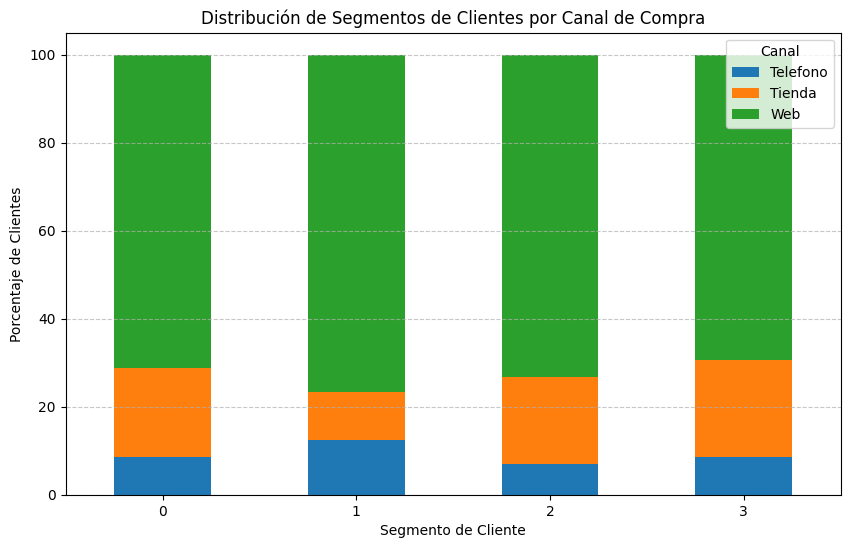

In [15]:
# Merge rfm with the original df to get 'canal' and 'provincia_envio'
df_segmented = pd.merge(rfm, df[['id_cliente', 'canal', 'provincia_envio']], on='id_cliente', how='left')

# Drop duplicates based on id_cliente to ensure each customer is counted once for 'canal' and 'provincia_envio'
df_segmented = df_segmented.drop_duplicates(subset=['id_cliente'])

# Distribution by 'canal'
distribucion_canal = df_segmented.groupby(['Segmento_Final', 'canal']).size().unstack(fill_value=0)

# Convert to percentage for better comparison
distribucion_canal_pct = distribucion_canal.apply(lambda x: x / x.sum() * 100, axis=1)

print("Distribución de Segmentos por Canal de Compra (Número de Clientes):")
print(distribucion_canal)
print("\nDistribución de Segmentos por Canal de Compra (Porcentaje):")
print(distribucion_canal_pct.round(2))

# Plotting the distribution by 'canal'
distribucion_canal_pct.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Distribución de Segmentos de Clientes por Canal de Compra')
plt.xlabel('Segmento de Cliente')
plt.ylabel('Porcentaje de Clientes')
plt.xticks(rotation=0)
plt.legend(title='Canal')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Análisis de la Distribución de Segmentos por Provincia de Envío
Ahora, veremos cómo se distribuyen los segmentos a lo largo de las diferentes provincias. Para una mejor visualización, mostraremos las principales provincias.

### Análisis del Importe Promedio por Canal y Segmento
Vamos a analizar el gasto promedio (Importe) de los clientes de cada segmento, desglosado por el canal de compra.

Importe Promedio por Canal para cada Segmento de Cliente:
canal           Telefono   Tienda      Web
Segmento_Final                            
0                1263.60  1455.92  1298.83
1                 310.77   372.17   334.82
2                 403.55   339.84   315.59
3                 308.40   252.33   241.34


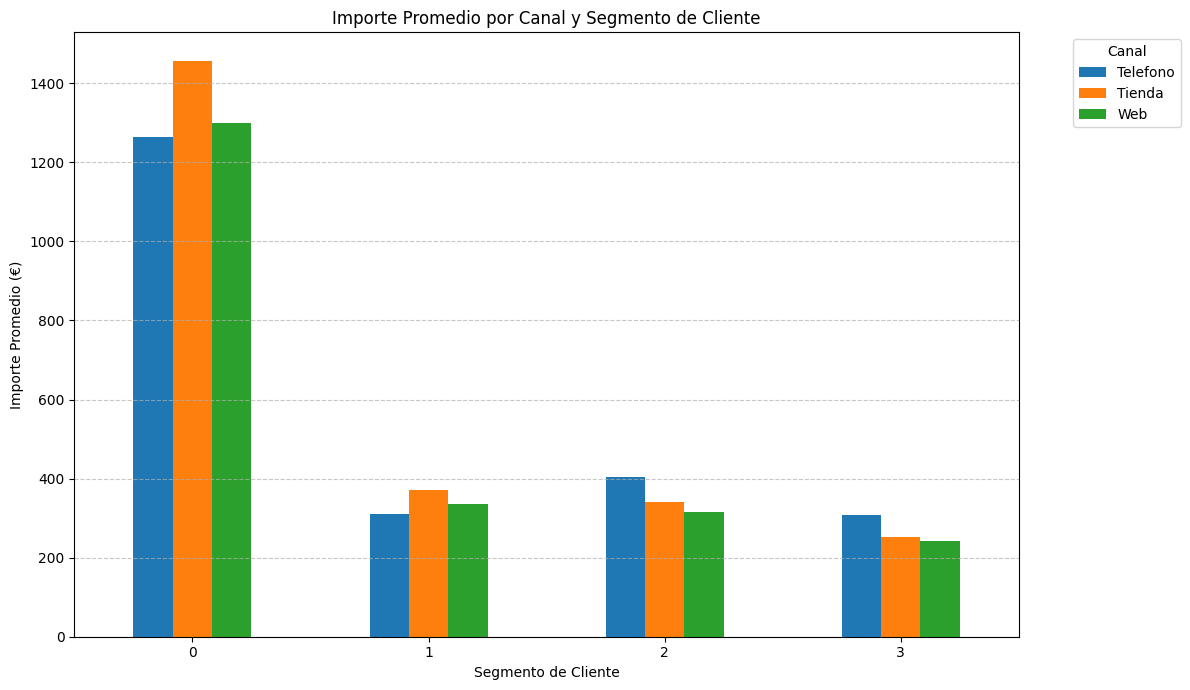

In [17]:
# Calcular el Importe promedio por Segmento_Final y canal
promedio_importe_canal_segmento = df_segmented.groupby(['Segmento_Final', 'canal'])['Importe'].mean().unstack(fill_value=0)

print("Importe Promedio por Canal para cada Segmento de Cliente:")
print(promedio_importe_canal_segmento.round(2))

# Visualizar el Importe promedio por canal y segmento
promedio_importe_canal_segmento.plot(kind='bar', figsize=(12, 7))
plt.title('Importe Promedio por Canal y Segmento de Cliente')
plt.xlabel('Segmento de Cliente')
plt.ylabel('Importe Promedio (€)')
plt.xticks(rotation=0)
plt.legend(title='Canal', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparación de Ventas y Devoluciones por Segmento
Para analizar la relación entre ventas y devoluciones por cada segmento de cliente, primero debemos clasificar cada transacción del conjunto de datos original como 'Venta' o 'Devolución' y luego agruparlas por segmento.

Comparación de Ventas y Devoluciones por Segmento:


tipo_transaccion,Devolucion,Venta,Tasa_Devolucion
Segmento_Final,,,
0,728.25,78339.74,0.93
1,134.46,51740.96,0.26
2,194.46,42764.48,0.45
3,282.73,43911.05,0.64


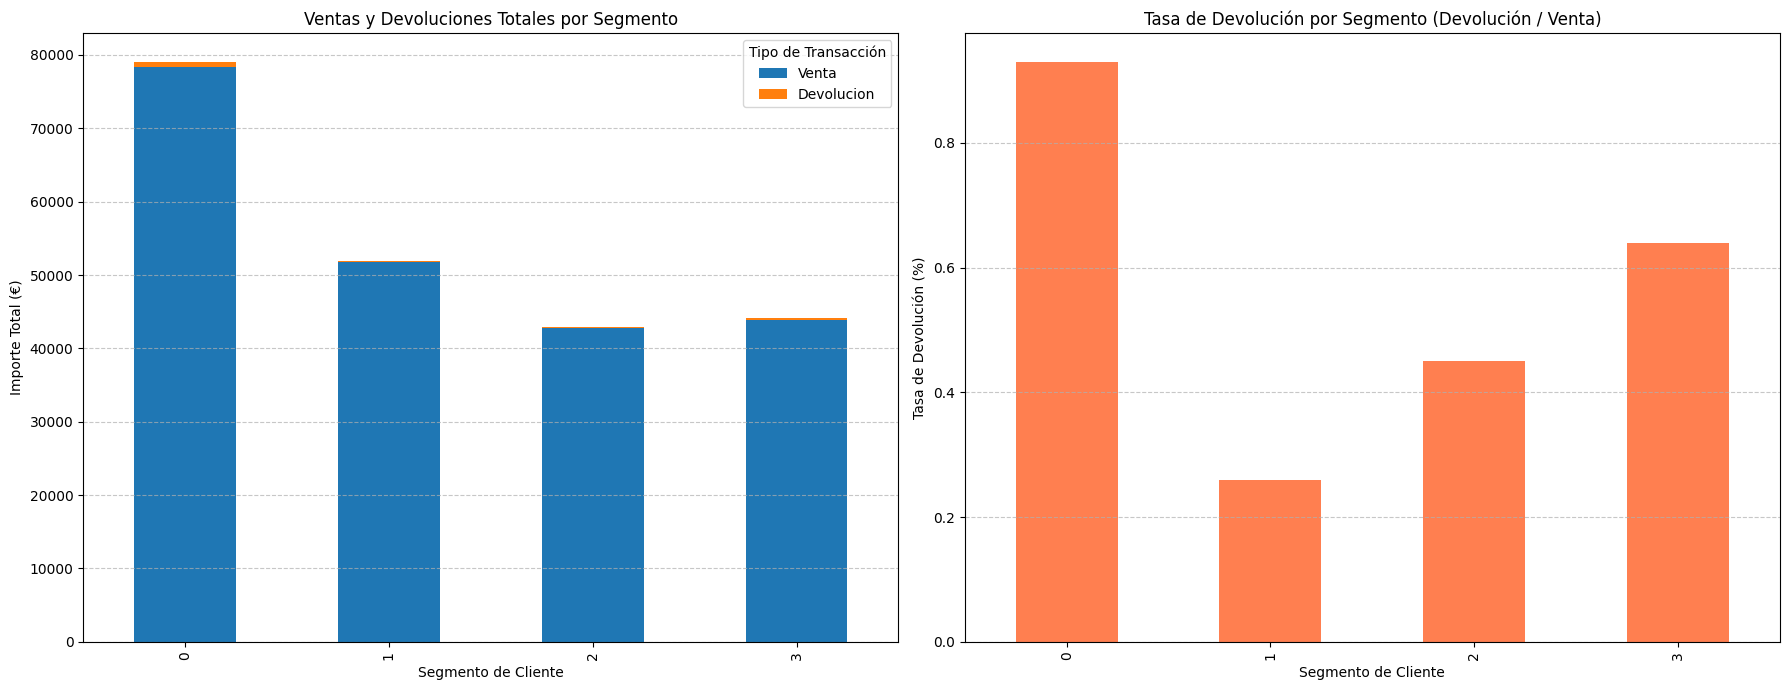

In [19]:
# Re-load the original data to get all transactions, including returns
df_original_transactions = pd.read_csv('despensa_atlantica_pedidos - despensa_atlantica_pedidos.csv')

# Apply duplicate removal (as done in CELDA 3)
df_original_transactions = df_original_transactions.drop_duplicates()

# Apply missing 'provincia_envio' imputation (as done in CELDA 3)
df_original_transactions['provincia_envio'] = df_original_transactions['provincia_envio'].fillna('No especificada')

# Classify transactions as sales or returns
df_original_transactions['tipo_transaccion'] = np.where(
    df_original_transactions['id_pedido'].str.startswith('DEV-', na=False),
    'Devolucion',
    'Venta'
)

# Merge with the Segmento_Final from the rfm DataFrame
# We need to ensure that 'id_cliente' is consistent in both DataFrames
transactions_with_segments = pd.merge(
    df_original_transactions,
    rfm[['id_cliente', 'Segmento_Final']],
    on='id_cliente',
    how='left'
)

# Create a new column with absolute importe_total for returns, and original for sales
transactions_with_segments['importe_ajustado'] = np.where(
    transactions_with_segments['tipo_transaccion'] == 'Devolucion',
    transactions_with_segments['importe_total'].abs(),
    transactions_with_segments['importe_total']
)

# Aggregate sales and returns by segment using importe_ajustado
sales_returns_by_segment = transactions_with_segments.groupby(['Segmento_Final', 'tipo_transaccion'])['importe_ajustado'].sum().unstack(fill_value=0)

# Calculate return rate
# Ensure 'Venta' is not zero to avoid division by zero
sales_returns_by_segment['Tasa_Devolucion'] = (
    sales_returns_by_segment['Devolucion'] / sales_returns_by_segment['Venta'] * 100
).fillna(0).round(2)

print("Comparación de Ventas y Devoluciones por Segmento:")
display(sales_returns_by_segment)

# Visualize the data
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot total sales and returns
sales_returns_by_segment[['Venta', 'Devolucion']].plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('Ventas y Devoluciones Totales por Segmento')
axes[0].set_xlabel('Segmento de Cliente')
axes[0].set_ylabel('Importe Total (€)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(title='Tipo de Transacción')
axes[0].ticklabel_format(style='plain', axis='y') # Avoid scientific notation for y-axis

# Plot return rate
sales_returns_by_segment['Tasa_Devolucion'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Tasa de Devolución por Segmento (Devolución / Venta)')
axes[1].set_xlabel('Segmento de Cliente')
axes[1].set_ylabel('Tasa de Devolución (%)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].ticklabel_format(style='plain', axis='y') # Avoid scientific notation for y-axis

plt.tight_layout()
plt.show()

### Cálculo y Análisis del Lifetime Value (LTV) por Segmento
El Lifetime Value (LTV) nos indica el valor monetario total que un cliente aportará a la empresa durante toda su relación. Dada la información disponible, calcularemos un LTV promedio por segmento basado en el 'Importe' (gasto total) de los clientes dentro del período de observación del conjunto de datos.

Lifetime Value Promedio por Segmento:


,Segmento_Final,LTV_Promedio
0,0,1327.79
1,1,335.98
2,2,326.45
3,3,249.49


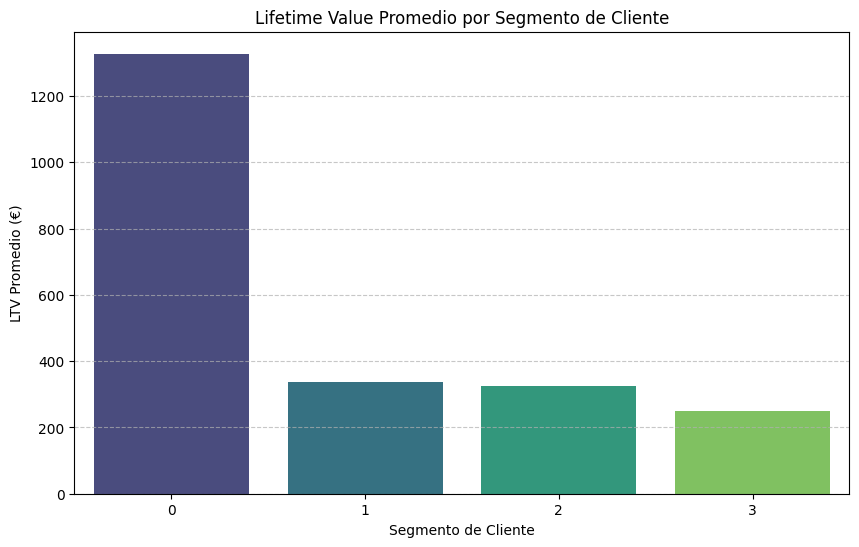

In [20]:
# Calcular el LTV (Importe Medio) para cada segmento
ltv_por_segmento = rfm.groupby('Segmento_Final')['Importe'].mean().reset_index()
ltv_por_segmento.rename(columns={'Importe': 'LTV_Promedio'}, inplace=True)

print("Lifetime Value Promedio por Segmento:")
display(ltv_por_segmento.round(2))

# Visualizar el LTV por segmento
plt.figure(figsize=(10, 6))
sns.barplot(x='Segmento_Final', y='LTV_Promedio', data=ltv_por_segmento, palette='viridis')
plt.title('Lifetime Value Promedio por Segmento de Cliente')
plt.xlabel('Segmento de Cliente')
plt.ylabel('LTV Promedio (€)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.show()

Distribución de Segmentos por Provincia de Envío (Número de Clientes - Top 5 Provincias):
provincia_envio  Santa Cruz de Tenerife  Las Palmas  Madrid  Barcelona  \
Segmento_Final                                                           
0                                    21          18       5          7   
1                                    54          52      21         14   
2                                    47          38      24         11   
3                                    56          43      35         19   

provincia_envio  Peninsula (resto)  
Segmento_Final                      
0                                6  
1                                8  
2                                9  
3                               19  

Distribución de Segmentos por Provincia de Envío (Porcentaje - Top 5 Provincias):
provincia_envio  Santa Cruz de Tenerife  Las Palmas  Madrid  Barcelona  \
Segmento_Final                                                           
0           

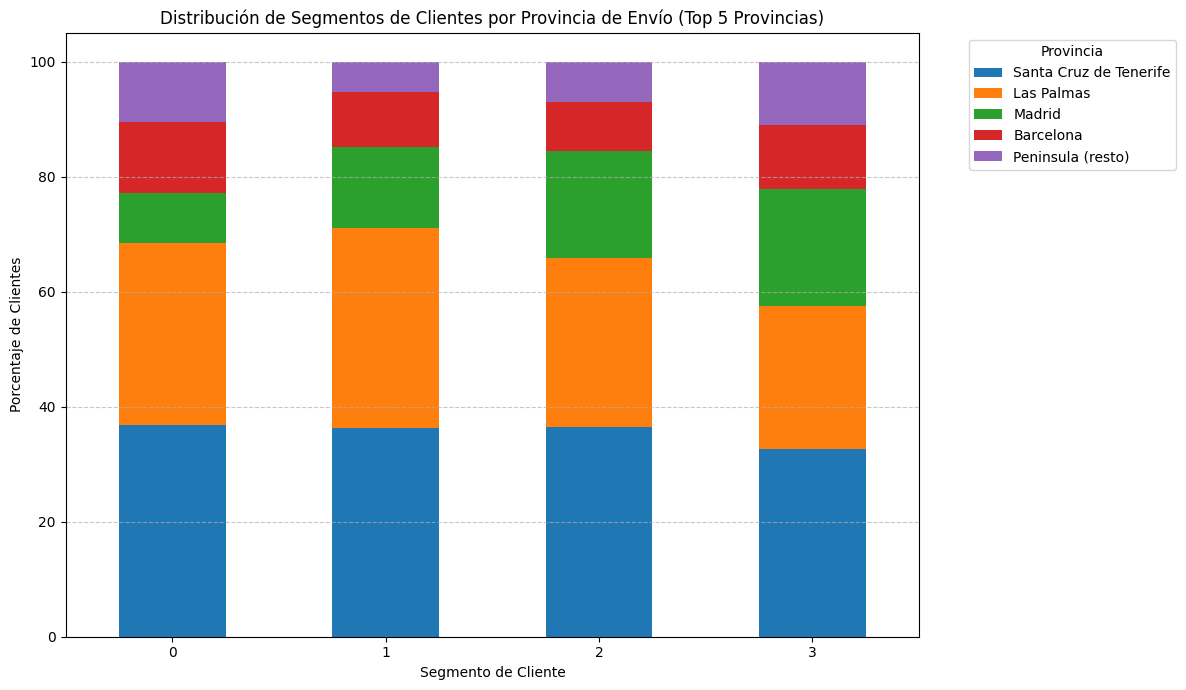

In [16]:
# Distribution by 'provincia_envio'
distribucion_provincia = df_segmented.groupby(['Segmento_Final', 'provincia_envio']).size().unstack(fill_value=0)

# Select top N provinces for visualization (e.g., top 5 or 10, adjust as needed)
top_provinces = df_segmented['provincia_envio'].value_counts().nlargest(5).index
distribucion_provincia_top = distribucion_provincia[top_provinces]

# Convert to percentage for better comparison
distribucion_provincia_pct = distribucion_provincia_top.apply(lambda x: x / x.sum() * 100, axis=1)

print("Distribución de Segmentos por Provincia de Envío (Número de Clientes - Top 5 Provincias):")
print(distribucion_provincia_top)
print("\nDistribución de Segmentos por Provincia de Envío (Porcentaje - Top 5 Provincias):")
print(distribucion_provincia_pct.round(2))

# Plotting the distribution by 'provincia_envio'
distribucion_provincia_pct.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Distribución de Segmentos de Clientes por Provincia de Envío (Top 5 Provincias)')
plt.xlabel('Segmento de Cliente')
plt.ylabel('Porcentaje de Clientes')
plt.xticks(rotation=0)
plt.legend(title='Provincia', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualización de los Segmentos RFM mediante Box Plots
Para entender las características de cada segmento, visualizaremos la distribución de Recencia, Frecuencia e Importe para cada grupo mediante diagramas de caja (box plots).

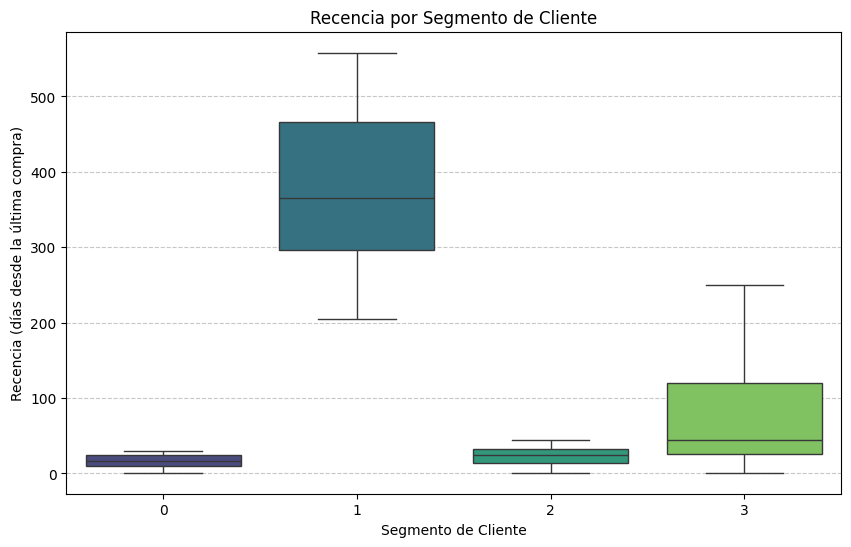

In [12]:
# Box plot para Recencia por Segmento
plt.figure(figsize=(10, 6))
sns.boxplot(x='Segmento_Final', y='Recencia', data=rfm, palette='viridis')
plt.title('Recencia por Segmento de Cliente')
plt.xlabel('Segmento de Cliente')
plt.ylabel('Recencia (días desde la última compra)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

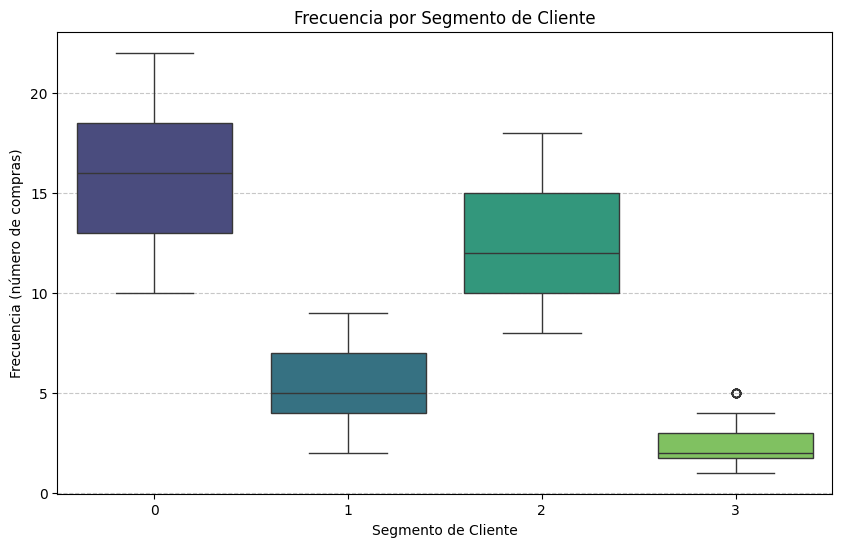

In [13]:
# Box plot para Frecuencia por Segmento
plt.figure(figsize=(10, 6))
sns.boxplot(x='Segmento_Final', y='Frecuencia', data=rfm, palette='viridis')
plt.title('Frecuencia por Segmento de Cliente')
plt.xlabel('Segmento de Cliente')
plt.ylabel('Frecuencia (número de compras)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

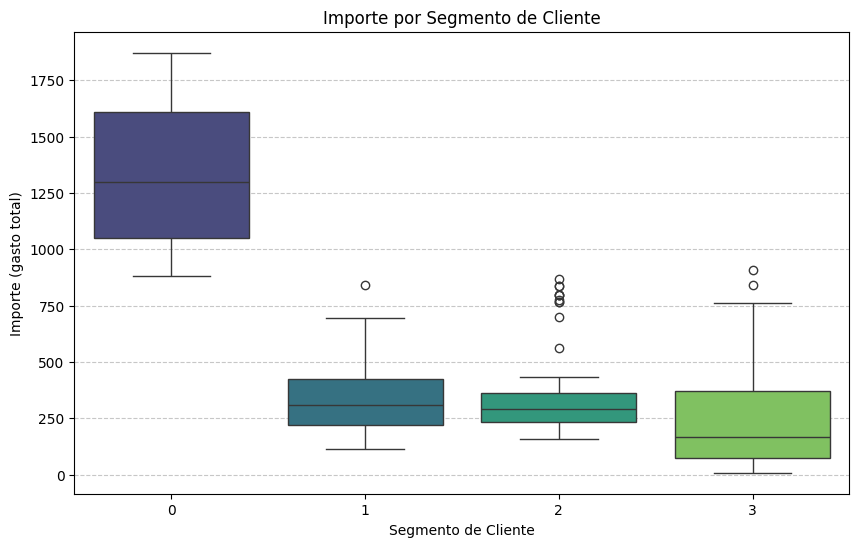

In [14]:
# Box plot para Importe por Segmento
plt.figure(figsize=(10, 6))
sns.boxplot(x='Segmento_Final', y='Importe', data=rfm, palette='viridis')
plt.title('Importe por Segmento de Cliente')
plt.xlabel('Segmento de Cliente')
plt.ylabel('Importe (gasto total)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()